# Setup & Load Data

tweets dataset - https://www.kaggle.com/datasets/kaushiksuresh147/bitcoin-tweets?select=Bitcoin_tweets_dataset_2.csv
sarcasm dataset - https://www.kaggle.com/datasets/danofer/sarcasm/data?select=train-balanced-sarcasm.csv

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import emoji
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack, csr_matrix

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [2]:
btc_df = pd.read_csv(
    "data/Bitcoin_tweets.csv",
    usecols=["date", "text"],   
    dtype={"text": "string"},
    parse_dates=["date"],
    low_memory=True
)
btc_df.head()


,date,text
0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


In [3]:
btc_df = btc_df[['date', 'text']].dropna()
btc_df.head()

,date,text
0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


In [4]:
sarc_df = pd.read_csv("data/train-balanced-sarcasm.csv")
sarc_df = sarc_df.rename(columns={"comment": "text"})

sarc_df = sarc_df[['label', 'text']].dropna()

sarc_df.head()


,label,text
0,0,NC and NH.
1,0,You do know west teams play against west teams...
2,0,"They were underdogs earlier today, but since G..."
3,0,"This meme isn't funny none of the ""new york ni..."
4,0,I could use one of those tools.


In [5]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sarc_df['text'] = sarc_df['text'].apply(clean_text)

# Training Sarcasm Model

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    sarc_df['text'],
    sarc_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=sarc_df['label']
)


In [7]:
# Word-level
word_vec = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Character-level (captures tone, elongation, sarcasm patterns)
char_vec = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=20000
)

X_train_word = word_vec.fit_transform(X_train)
X_val_word = word_vec.transform(X_val)

X_train_char = char_vec.fit_transform(X_train)
X_val_char = char_vec.transform(X_val)

In [8]:
def cap_features(texts):
    features = []
    
    for text in texts:
        total_chars = len(text)
        upper_chars = sum(1 for c in text if c.isupper())
        upper_ratio = upper_chars / total_chars if total_chars > 0 else 0
        
        has_all_caps_word = any(
            word.isupper() and len(word) > 2 
            for word in text.split()
        )
        
        features.append([upper_ratio, int(has_all_caps_word)])
    
    return np.array(features)

X_train_caps = cap_features(X_train)
X_val_caps = cap_features(X_val)

# Convert to sparse
X_train_caps = csr_matrix(X_train_caps)
X_val_caps = csr_matrix(X_val_caps)

In [9]:
X_train_vec = hstack([X_train_word, X_train_char, X_train_caps])
X_val_vec = hstack([X_val_word, X_val_char, X_val_caps])

In [10]:
model = LogisticRegression(
    max_iter=3000,
    C=2.0,
    class_weight='balanced'
)

model.fit(X_train_vec, y_train)

LogisticRegression(C=2.0, class_weight='balanced', max_iter=3000)

In [11]:

pred = model.predict(X_val_vec)
print(classification_report(y_val, pred))


              precision    recall  f1-score   support

           0       0.72      0.76      0.74    101081
           1       0.75      0.71      0.73    101074

    accuracy                           0.73    202155
   macro avg       0.74      0.73      0.73    202155
weighted avg       0.74      0.73      0.73    202155



In [12]:
def sarcasm_probability(text):
    text = clean_text(text)
    
    word_part = word_vec.transform([text])
    char_part = char_vec.transform([text])
    caps_part = csr_matrix(cap_features([text]))
    
    combined = hstack([word_part, char_part, caps_part])
    
    prob = model.predict_proba(combined)[0][1]
    return prob

In [13]:
sample_texts = [
    "Bitcoin is doing AMAZING 😂😂",
    "Yeah right, BTC is totally stable",
    "Bitcoin price rising steadily",
    "BTC crashing hard today",
    "YEAHHH BITCOING IS SO GOOOOOOD"
]

for t in sample_texts:
    print(t)
    print("Sarcasm prob:", sarcasm_probability(t))
    print()


Bitcoin is doing AMAZING 😂😂
Sarcasm prob: 0.7637832720302764

Yeah right, BTC is totally stable
Sarcasm prob: 0.9943080208460428

Bitcoin price rising steadily
Sarcasm prob: 0.5045632095641677

BTC crashing hard today
Sarcasm prob: 0.5807462357981966

YEAHHH BITCOING IS SO GOOOOOOD
Sarcasm prob: 0.7822634833501683



In [35]:
import pickle
import os

os.makedirs("model", exist_ok=True)

model_bundle = {
    "model": model,
    "word_vec": word_vec,
    "char_vec": char_vec
}

with open("model/sarcasm_bundle.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

# Making a sentiment analyser

In [13]:

analyzer = SentimentIntensityAnalyzer()

def extract_emojis(text):
    return ''.join(c for c in str(text) if c in emoji.EMOJI_DATA)

def remove_emojis(text):
    return ''.join(c for c in str(text) if c not in emoji.EMOJI_DATA)



In [14]:
emoji_sentiment = {
    # Bullish
    "🚀": 0.95, "📈": 0.85, "💰": 0.80, "💎": 0.75,
    "🤑": 0.80, "🔥": 0.70, "🐂": 0.85,
    "💪": 0.60, "🎉": 0.75, "🥳": 0.75,
    "⭐": 0.60, "🏆": 0.75, "👑": 0.70,
    "🪙": 0.70, "💵": 0.70, "💴": 0.65,
    "💯": 0.65, "🌕": 0.80, "🌟": 0.70,

    # Bearish
    "📉": -0.90, "🔻": -0.75, "🔴": -0.70,
    "🐻": -0.85, "💥": -0.70, "🛑": -0.75,
    "❌": -0.70, "💔": -0.75, "😭": -0.70,
    "😡": -0.75, "🤡": -0.65, "💀": -0.80,
    "😱": -0.65, "💣": -0.80, "🚨": -0.60,

    # Market-specific
    "🐳": 0.40, "🐋": 0.40,
    "⛏": 0.30, "⚡": 0.30,
    "📊": 0.20, "🔗": 0.20, "🌐": 0.20,

    # Sarcasm-sensitive
    "😂": -0.20, "🤣": -0.20,
    "🙄": -0.30, "😉": -0.10,
    "😏": -0.20, "🤔": 0.00,
    "👀": 0.10
}


In [15]:
def emoji_score(emojis):
    if not emojis:
        return 0
    
    scores = [emoji_sentiment.get(e, 0) for e in emojis]
    
    # repetition intensity boost
    intensity = 1 + 0.1 * (len(emojis) - 1)
    
    return np.mean(scores) * intensity


In [16]:
def baseline_vader(text):
    return analyzer.polarity_scores(str(text))['compound']

def emoji_vader(text, alpha=0.7, beta=0.3):
    """
    Combine text sentiment and emoji sentiment.
    """

    text = str(text)

    emojis = extract_emojis(text)
    text_clean = remove_emojis(text)

    s_text = analyzer.polarity_scores(text_clean)["compound"]
    s_emoji = emoji_score(emojis)

    return alpha * s_text + beta * s_emoji

def es_vader(text, alpha=0.7, beta=0.3, lambda_sarc=0.8):
    """
    Emoji + VADER + Sarcasm adjustment.
    """

    text = str(text)

    emojis = extract_emojis(text)
    text_clean = remove_emojis(text)

    s_text = analyzer.polarity_scores(text_clean)["compound"]
    s_emoji = emoji_score(emojis)

    s_base = alpha * s_text + beta * s_emoji

    # sarcasm probability
    s_prob = sarcasm_probability(text)

    # only activate sarcasm when strong
    adjusted_prob = max(0, s_prob - 0.6)

    s_final = s_base * (1 - lambda_sarc * adjusted_prob)

    return s_final


In [17]:

btc_df = btc_df.sample(n=150_000, random_state=42)

btc_df["vader_score"] = btc_df["text"].apply(baseline_vader)
btc_df["emoji_vader_score"] = btc_df["text"].apply(emoji_vader)
btc_df["es_score"] = btc_df["text"].apply(es_vader)

btc_df.head()

,date,text,vader_score,emoji_vader_score,es_score
4300626,2022-10-12 16:12:45,#Bitcoin scenario (yellow line) is painful wha...,-0.4404,-0.30828,-0.308280
703579,2021-07-26 04:45:04,🚨🐋 THERE WAS A LARGE BITCOIN (584.9999707 BTC)...,0.0000,-0.03900,-0.039000
250956,2021-06-20 18:49:56,"#bitcoin has no top, because #fiat has no bott...",-0.4199,-0.29393,-0.229728
1053086,2021-08-18 01:30:25,#YieldFarming #Airdrop #PancakeSwap #BTC #Bina...,-0.5106,0.56028,0.560280
4293814,2022-10-12 22:29:10,You could activate your Susumi Wallet today an...,0.6369,0.44583,0.445830


In [18]:
# %% [markdown]
# ## Convert Scores to Sentiment Labels

# %%
def label_sentiment(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"


btc_df["vader_label"] = btc_df["vader_score"].apply(label_sentiment)
btc_df["es_label"] = btc_df["es_score"].apply(label_sentiment)

In [20]:
btc_df["date"] = pd.to_datetime(btc_df["date"], errors="coerce")

btc_df = btc_df.dropna(subset=["date"])

btc_df = btc_df.set_index("date")

In [ ]:
one_min_vader = btc_df["vader_score"].resample("1T").mean()
one_min_es = btc_df["es_score"].resample("1T").mean()

five_min_vader = btc_df["vader_score"].resample("5T").mean()
five_min_es = btc_df["es_score"].resample("5T").mean()

fifteen_min_vader = btc_df["vader_score"].resample("15T").mean()
fifteen_min_es = btc_df["es_score"].resample("15T").mean()

one_hour_vader = btc_df["vader_score"].resample("1H").mean()
one_hour_es = btc_df["es_score"].resample("1H").mean()

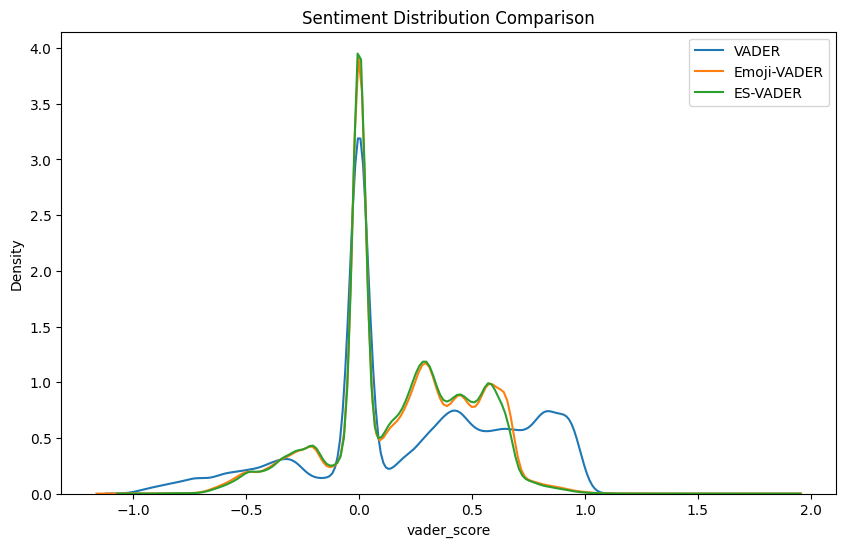

In [22]:
plt.figure(figsize=(10,6))

sns.kdeplot(btc_df["vader_score"], label="VADER")
sns.kdeplot(btc_df["emoji_vader_score"], label="Emoji-VADER")
sns.kdeplot(btc_df["es_score"], label="ES-VADER")

plt.title("Sentiment Distribution Comparison")
plt.legend()
plt.show()

In [23]:
from scipy.stats import ttest_rel

ttest_rel(btc_df["vader_score"], btc_df["es_score"])

TtestResult(statistic=95.81163372044217, pvalue=0.0, df=149998)

In [32]:
sample_test = btc_df.sample(5)

for _, row in sample_test.iterrows():

    print("="*80)
    print("Tweet:", row["text"])

    print("\nScores:")
    print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
    print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
    print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")

Tweet: @farokh #creoengine
Developing and deploying games is easy now 🚀⚡
Best #Decentralised platform for game developers and also serves for developing games and #NFT Marketplace provider
TGE &amp; IDO ON MARCH 2022⚡
Pre-Public Sale on 8-15March🔥
More:
@Creo_engine   #creo #bsc #btc

Scores:
VADER       : 0.6908 (Positive)
Emoji-VADER : 0.7769
ES-VADER    : 0.7769 (Positive)
Tweet: @mozilla #Bitcoin with lightning. Free and instant, close to 0 energy usage. That should have been the way. Instead you surfed on the dogecoin ponzi and ruined the hard built reputation

Scores:
VADER       : 0.2263 (Positive)
Emoji-VADER : 0.1584
ES-VADER    : 0.1584 (Positive)
Tweet: 🔥 Today's TOP 10 cryptocurrencies all fell, among which #Terra (#LUNA) fell the most, falling more than 8.3% to around $78.8201.
 ·
 #BTC slipped 🔽 3.15% to around $38,012;
 #ETH is down 🔽 4.14% around $2,528.
 ·

Scores:
VADER       : -0.1926 (Negative)
Emoji-VADER : 0.1981
ES-VADER    : 0.1981 (Positive)
Tweet: 🚨🐋 THERE WAS